In [1]:
from blended_measurement import blended_measurement
from random_measurement import random_measurement
from qiskit.extensions import *
from qiskit.circuit.add_control import add_control
from qiskit import  BasicAer,transpile, QuantumRegister, ClassicalRegister, QuantumCircuit
import numpy as np

import sys
print(sys.executable)


/bin/python3


{'1': 966, '0': 58}
{'1': 1012, '0': 12}
{'1': 999, '0': 25}
{'1': 1012, '0': 12}
{'1': 928, '0': 96}
{'1': 943, '0': 81}
{'1': 714, '0': 310}
{'1': 653, '0': 371}
{'1': 772, '0': 252}
{'1': 988, '0': 36}


/home/jason/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/jason/.local/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


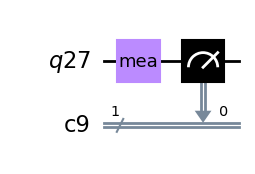

In [2]:
m=10
d=2
measurement_set=[random_measurement(d,i) for i in range(m)]
blended_set=blended_measurement(measurement_set,d,m)
operator=[]
for item in blended_set:
    item=item.astype(np.complex128)
    eigval, eigenvector=np.linalg.eigh(item)
    operator.append(eigenvector@eigenvector)
    # print(operator)


for i in range(m):
    q = QuantumRegister(1)
    c = ClassicalRegister(1)
    qc = QuantumCircuit(q, c)
    
    qc.unitary(operator[i],0,label="mea")

    qc.measure(q[0], c[0])
    backend = BasicAer.get_backend('qasm_simulator') # create a new backend for any new circuit
    tqc = transpile(qc, backend) # connect bacjend and the circuit
    counts = backend.run(tqc).result().get_counts() # get the result
    print(counts)

qc.draw('mpl')